In [1]:
import ast
import concurrent.futures
import glob
import itertools
import os
import pickle
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

import dask
import dask.dataframe as dd
import dask_ml.cluster as dask_cluster
from dask.distributed import Client
from dask.diagnostics import ProgressBar

from concurrent.futures import ThreadPoolExecutor
from joblib import Parallel, delayed
from multiprocessing import Pool, cpu_count

from sklearn.linear_model import LinearRegression
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
#from sklearn.cluster import KMeans

from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm
from collections import Counter
from functools import reduce
from pprint import pprint

pd.set_option('display.max_columns', None)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

### Illustrate TCV

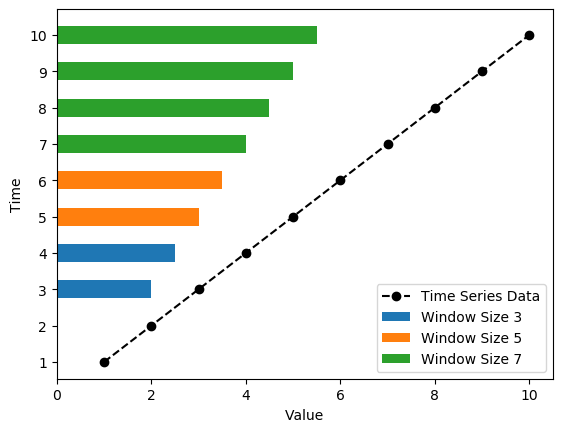

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Define the time series data
time_series = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Define the expanding window sizes
window_sizes = [3, 5, 7]

# Initialize the figure and axis
fig, ax = plt.subplots()

# Iterate over the window sizes
for i, window_size in enumerate(window_sizes):
    # Perform expanding window cross-validation
    predictions = []
    for j in range(len(time_series) - window_size + 1):
        window_data = time_series[:j + window_size]
        prediction = np.mean(window_data)  # Simple averaging as an example
        predictions.append(prediction)

    # Plot the predictions as horizontal bars
    ax.barh(np.arange(window_size - 1, len(time_series)), predictions,
            height=0.5, label=f'Window Size {window_size}')

# Plot the time series data
ax.plot(time_series, np.arange(len(time_series)), 'ko--', label='Time Series Data')

# Set y-axis ticks and labels
ax.set_yticks(np.arange(len(time_series)))
ax.set_yticklabels(range(1, len(time_series) + 1))

# Set labels and legend
ax.set_xlabel('Value')
ax.set_ylabel('Time')
ax.legend()

# Show the plot
plt.show()
